This is a implementation of the Kuster-Toksoz model on the original probablistic inversion with mcmc.

In [ ]:
import numpy as np
import emcee
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")

In [2]:
# ----- Fluid End-Member Properties -----
K_water = 2.2e9      # Bulk modulus of water in Pa
rho_water = 1000.0   # Density of water in kg/m³

K_gas = 1e5          # Bulk modulus for gas (e.g., CO₂) in Pa
rho_gas = 1.8        # Density for gas in kg/m³

In [3]:
def pq_from_alpha(alpha, k_m, mu_m, k_i, mu_i, eps=0.0):
    if alpha <= 0 or alpha > 1:
        return None, None, None

    # Auxiliaries (matrix-based)
    beta_m = mu_m * (3.0*k_m + mu_m) / (3.0*k_m + 4.0*mu_m)
    zeta_m = mu_m * (9.0*k_m + 8.0*mu_m) / (6.0*(k_m + 2.0*mu_m))
    zeta_i = mu_i * (9.0*k_m + 8.0*mu_m) / (6.0*(k_m + 2.0*mu_m))

    if alpha <= 1e-2:
        shape = "penny"
        denom_P = k_i + (4.0/3.0)*mu_i + np.pi*alpha*beta_m + eps
        P = (k_m + (4.0/3.0)*mu_i) / denom_P
        term1 = 1.0
        term2 = 8.0*mu_m / (4.0*mu_i + np.pi*alpha*(mu_m + 2.0*beta_m) + eps)
        term3 = 2.0 * (k_i + (2.0/3.0)*(mu_i + mu_m)) / (k_i + (4.0/3.0)*mu_i + np.pi*alpha*beta_m + eps)
        Q = 0.2 * (term1 + term2 + term3)
    else:
        shape = "sphere"
        P = (k_m + (4.0/3.0)*mu_m) / (k_i + (4.0/3.0)*mu_m + eps)
        Q = (mu_m + zeta_m) / (mu_i + zeta_m + eps)

    return float(P), float(Q), shape

In [4]:
import numpy as np

def kt_effective(
    k_m, mu_m,                 # matrix (host) bulk and shear moduli
    phi, S_w, alpha,           # porosity, water saturation, aspect ratio (oblate c/a)
    k_w, k_g,                  # water & gas bulk moduli
    mu_w=0.0, mu_g=0.0,        # water & gas shear moduli (fluids -> 0 in quasi-static)
    pq_func=None,              # function(alpha, k_m, mu_m, k_i, mu_i) -> (P, Q)
    eps=1e-8                    # tiny stabilizer for near-singular denominators (optional)
):
    if pq_func is None:
        raise ValueError("Provide pq_func(alpha, k_m, mu_m, k_i, mu_i) to compute (P, Q).")

    # ---- auxiliary (matrix) ----
    zeta_m = mu_m * (9.0 * k_m + 8.0 * mu_m) / (6.0 * (k_m + 2.0 * mu_m))

    # ---- inclusion P,Q for water and gas ----
    P_w, Q_w, Sh_w = pq_func(alpha, k_m, mu_m, k_w, mu_w)
    P_g, Q_g, Sh_g = pq_func(alpha, k_m, mu_m, k_g, mu_g)
    #print(P_w, Q_w, P_g, Q_g, Sh_w, Sh_g)
    A = S_w * phi * (k_w - k_m) * P_w + (1.0 - S_w) * phi * (k_g - k_m) * P_g
    B = S_w * phi * (mu_w - mu_m) * Q_w + (1.0 - S_w) * phi * (mu_g - mu_m) * Q_g

    # ---- Solve algebraically for k_e and mu_e ----
    # From: ((k_e - k_m)*(k_m + 4/3 mu_m))/(k_e + 4/3 mu_m) = A
    a = k_m + (4.0 / 3.0) * mu_m
    #print(a-A)
    k_e = (a * k_m + (4.0 / 3.0) * A * mu_m) / (a - A + eps)

    # From: ((mu_e - mu_m)*(mu_m + zeta_m))/(mu_e + zeta_m) = B
    b = mu_m + zeta_m
    mu_e = (b * mu_m + B * zeta_m) / (b - B + eps)

    return k_e, mu_e

In [5]:
def effective_density(rho_m, rho_i, phi):
    """
    Effective density ρ* = (1 - φ)*ρ_m + φ*ρ_i
    """
    return (1 - phi) * rho_m + phi * rho_i

In [6]:
def seismic_velocities(K_eff, mu_eff, rho_eff):
    """
    Compute seismic velocities:
      Vp = sqrt((K_eff + 4/3*mu_eff)/ρ_eff)
      Vs = sqrt(mu_eff/ρ_eff)
    """
    Vp = np.sqrt((K_eff + (4.0/3.0)*mu_eff) / rho_eff)
    Vs = np.sqrt(mu_eff / rho_eff)
    return Vp, Vs

In [ ]:
def forward(theta):
    """
    Forward model mapping unknown parameters to effective seismic properties.
    
    theta = [S_w, phi, log10(alpha), K_m, mu_m, rho_m]
      S_w: water saturation (0 to 1)
      phi: crack porosity (volume fraction)
      log10(alpha): log10 of crack aspect ratio
      K_m: matrix bulk modulus (Pa)
      mu_m: matrix shear modulus (Pa)
      rho_m: matrix density (kg/m³)
      
    Returns: [Vp, Vs, rho_eff]
    """
    theta = np.asarray(theta).ravel()
    S_w, phi, logalpha, K_m, mu_m, rho_m = theta
    alpha = 10**(logalpha)
    rho_i = S_w * rho_water + (1 - S_w) * rho_gas
    K_eff, mu_eff = kt_effective(K_m, mu_m, phi, S_w, alpha, K_water, K_gas, mu_w=0, mu_g= 0, pq_func=pq_from_alpha)
    rho_eff = effective_density(rho_m, rho_i, phi)
    if (K_eff <= 0) or (mu_eff <= 0) or (rho_eff <= 0):
        return np.array([-np.inf, -np.inf, -np.inf])
    Vp, Vs = seismic_velocities(K_eff, mu_eff, rho_eff)
    return np.array([Vp, Vs, rho_eff])

In [8]:
Vp_obs =4700.0       # m/s (5 km/s)
Vs_obs = 2700.0       # m/s (2.8 km/s)
# Assume observed effective density with matrix density ~3000 kg/m³ and water-filled pores:
rho_obs =  2589
sigma_Vp = 300.0       # m/s
sigma_Vs = 100.0       # m/s
sigma_rho = 167.0   

In [ ]:
def log_likelihood(theta):
    model = forward(theta)  # [Vp, Vs, rho_eff]
    diff = model - np.array([Vp_obs, Vs_obs, rho_obs])
    chi2 = (diff[0]**2/sigma_Vp**2 +
            diff[1]**2/sigma_Vs**2 +
            diff[2]**2/sigma_rho**2)
    return -0.5 * chi2

In [ ]:
def log_prior(theta):
    theta = np.asarray(theta).ravel()
    S_w, phi, logalpha, K_m, mu_m, rho_m = theta
    # Uniform priors over plausible ranges:
    if (0.001 < S_w < 1.0 and 
        0.001 < phi < 0.5 and 
        -3.0 < logalpha < 0.0 and 
        756e8 < K_m < 80e9 and
        256e8 < mu_m < 40e9 and
        2680 < rho_m < 2900):
        return 0.0
    return -np.inf

In [ ]:
def log_post(theta):
    theta = np.asarray(theta).ravel()
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf, np.full(3, -np.inf)
    ll = log_likelihood(theta)
    blob = forward(theta)  # Blob: [Vp, Vs, rho_eff]
    return lp + ll, blob

In [ ]:
lb = np.array([0.001, 0.001, -3.0, 756e8, 256e8, 2680])
ub = np.array([1.0, 0.5, 0.0, 80e9, 40e9, 2900])
n = np.shape(ub)[0]
H = np.array([1,1,1], dtype=int)
Ne = 3 * n
prior_pdf = np.random.uniform(lb, ub, (Ne, n))
d = np.array([Vp_obs, Vs_obs, rho_obs])
s = np.array([sigma_Vp, sigma_Vs, sigma_rho])
sampler = emcee.EnsembleSampler(Ne, n, log_post)
Nsteps = 50000
sampler.run_mcmc(prior_pdf, Nsteps, progress=True)
blobs = sampler.get_blobs()

# Extract samples and analyze results
samples = sampler.get_chain(flat=True)

# Identify best-fit sample
flat_log_prob = sampler.get_log_prob(flat=True)
best_idx = np.argmax(flat_log_prob)
best_params = samples[best_idx]
best_model = forward(best_params)

# Plot results
labels = ["Water Content", "Porosity", "Aspect Ratio", "Bulk Modulus", "Shear Modulus", "Density"]
fig, axes = plt.subplots(n, figsize=(10, 7), sharex=True)
for i in range(n):
    axes[i].plot(samples[:, i], "k", alpha=0.3)
    axes[i].set_ylabel(labels[i])
axes[-1].set_xlabel("Step Number")
plt.tight_layout()
plt.show()

In [ ]:
# ----- Get final, flat parameters from the sampler -----
chain = sampler.get_chain(flat=True)   # shape: (Nsamples, n)
# Parameter order: theta = [S_w, phi, log10(alpha), K_m, mu_m, rho_m]
IDX_SW  = 0
IDX_PHI = 1

# Keep only finite rows (extra safety if you ever stored bad states)
finite_mask = np.all(np.isfinite(chain), axis=1)
chain_good  = chain[finite_mask]
if chain_good.size == 0:
    raise RuntimeError("No finite samples found in parameter chain.")

# Extract parameters explicitly
S_w  = chain_good[:, IDX_SW]
phi  = chain_good[:, IDX_PHI]

# ----- Plot and save S_w and phi -----
import matplotlib.pyplot as plt

# Combined 2-row figure
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=False)

# Water saturation
axes[0].hist(S_w, bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Water Saturation, $S_w$")
axes[0].set_ylabel("Density")

# Porosity
axes[1].hist(phi, bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].set_title("Porosity, $\\phi$")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Density")

plt.tight_layout()
fig.savefig("water_saturation_and_porosity.png", dpi=200, bbox_inches='tight')
plt.close(fig)

In [ ]:
label = np.array(['water saturation', 'porosity', 'aspect ratio', 'mineral bulk modulus', 'mineral shear modulus', 'mineral density'])
param_names = list(label)

# Find the indices for porosity and water saturation
idx_porosity = param_names.index('porosity')
idx_water    = param_names.index('water saturation')

def plot_and_save(param_idx, param_name, minn, maxx, mayy, bins=100, filename=None):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(samples[:, param_idx], bins=bins, density=True, alpha=0.7, edgecolor='black')
    #ax.set_xlabel(param_name.capitalize())
    #ax.set_ylabel("Density")
    #ax.set_title(f"Histogram of {param_name.capitalize()}")
    ax.set_xlim(minn, maxx)
    ax.tick_params(
    axis='both',         # apply to both x & y axes
    which='major',       # only affect major ticks
    labelsize=20,        # font size of tick labels
    length=8,            # length of tick marks in points
    width=1.5            # width of the tick marks
    )
    ax.set_ylim(0, mayy)
    plt.tight_layout()
    if filename:
        fig.savefig(filename)
    plt.show()

np.save("saturation_kt.npy", idx_water)
np.save("porosity_kt.npy", idx_porosity)
# Porosity
plot_and_save(idx_porosity, 'crack porosity', 0, 0.5, 13, bins=100, filename='porosity_kt_5.png')

# Water saturation
plot_and_save(idx_water, 'water saturation', 0, 1.0, 6, bins=100, filename='saturation_kt_5.png')

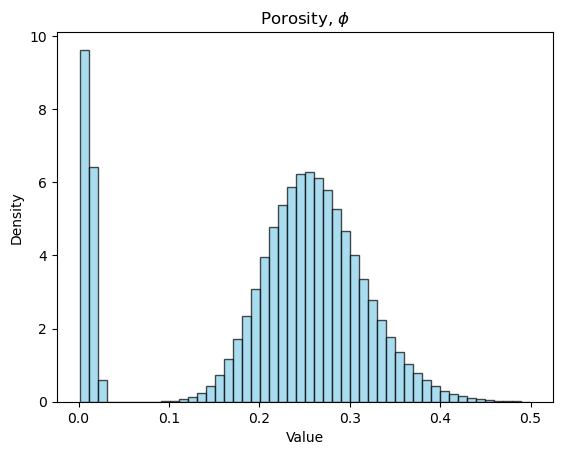

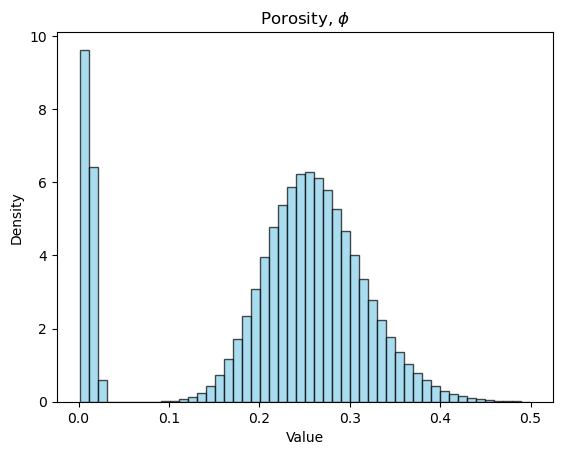

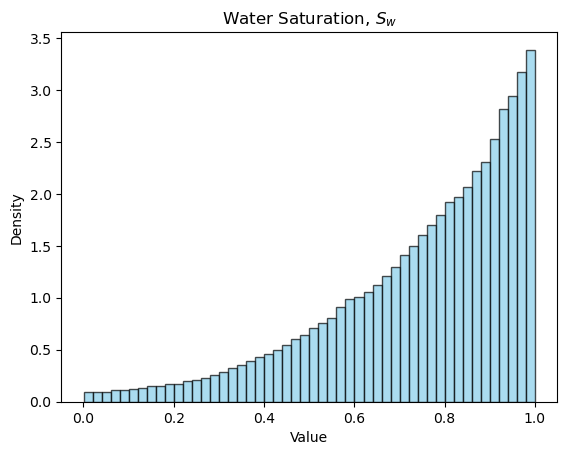

In [ ]:
def plot_1d_histograms(samples, labels=None, bins=100, savefig=None):
    n_parameters = samples.shape[1]  
    if labels is None:
        labels = [f"Parameter {i+1}" for i in range(n_parameters)]
    
    fig, axes = plt.subplots(n_parameters, 1, figsize=(8, 2 * n_parameters), sharex=False)
    if n_parameters == 1:
        axes = [axes]
    
    for i in range(n_parameters):
        ax = axes[i]
        ax.hist(samples[:, i], bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.7)
        ax.set_ylabel("Density")
        ax.set_title(labels[i])
    axes[-1].set_xlabel("Parameter Value")
    
    plt.tight_layout()
    
    plt.show()
    
    if savefig:
        plt.savefig(savefig)

In [ ]:
plot_1d_histograms(samples, labels = label, bins=100, savefig = 'kt_fig1.png')

In [ ]:
bb1 = blobs.reshape(-1, 3)
mask = np.all(np.isfinite(bb1), axis=1)
bb_good = bb1[mask]
post_lab = ['vp', 'vs', 'rhob']
plot_1d_histograms(bb_good, labels=post_lab, bins=100, savefig = "kt_fig2.png")

In [ ]:
K_water = 2.2e9      # Bulk modulus of water in Pa
rho_water = 1000.0   # Density of water in kg/m³

K_gas = 1e5          # Bulk modulus for gas (e.g., CO2) in Pa (very compressible)
rho_gas = 1.8        # Density for gas in kg/m³
best_S_w = best_params[0]    # Water saturation
best_phi = best_params[1]    # Porosity
S_w_from_K = best_S_w
S_w_from_rho = best_S_w

print("Best-fit water saturation: {:.3f}".format(best_S_w))
print("Best-fit porosity: {:.3f}".format(best_phi))

In [22]:
print(10*0.03*0.859)

0.2577


In [ ]:
def plot_2d_color_plots(samples, lab, savefig=None):
    """
    Plot 2D color maps (histograms) for selected pairs of MCMC parameters.
    
    Parameters:
      samples: numpy array of shape (N, ndim) with MCMC chain samples.
      lab:     list of parameter labels (length ndim).
      savefig: (Optional) Filename to save the figure (e.g., "my_2dplots.png").
    """
    # Extract individual variables from the samples.
    water_saturation = samples[:, 0]
    porosity = samples[:, 1]
    aspect_ratio = samples[:, 2]
    mineral_bulk_modulus = samples[:, 3]
    mineral_shear_modulus = samples[:, 4]
    mineral_density = samples[:, 5]

    # List of variables to plot.
    variables = [water_saturation, porosity, aspect_ratio, mineral_bulk_modulus,
                 mineral_shear_modulus, mineral_density]

    # Define a list of pair indices to plot.
    pairs = [
        (0, 1), (1, 2), (2, 3), (3, 4), (4, 5),  # First 5 pairs.
        (0, 2), (1, 3), (2, 4), (3, 5),          # Next 4 pairs.
        (0, 3), (1, 4), (2, 5),                   # Next 3 pairs.
        (0, 4), (1, 5),                          # Next 2 pairs.
        (0, 5), (1, 0)                           # Last 2 pairs to complete the grid.
    ]
    total_pairs = len(pairs)

    # Create a grid for the subplots.
    nrows = 5
    ncols = 3
    fig, axs = plt.subplots(nrows, ncols, figsize=(15, 15))
    
    plot_counter = 0
    for i in range(nrows):
        for j in range(ncols):
            if plot_counter < total_pairs:
                x_idx, y_idx = pairs[plot_counter]

                # Select the pair of variables to plot.
                x_var = variables[x_idx]
                y_var = variables[y_idx]

                # Compute the 2D histogram with 100 bins per axis.
                hist, x_edges, y_edges = np.histogram2d(x_var, y_var, bins=100)

                # Plot the 2D color map using imshow.
                im = axs[i, j].imshow(hist.T, extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
                                        origin="lower", aspect="auto", cmap="viridis")
                axs[i, j].set_title(f"{lab[y_idx]} vs {lab[x_idx]}")
                axs[i, j].set_xlabel(lab[x_idx])
                axs[i, j].set_ylabel(lab[y_idx])
                
                plot_counter += 1
            else:
                axs[i, j].axis('off')
    
    fig.tight_layout()
    fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.02, pad=0.04)
    
    
    plt.show()
    if savefig:
        plt.savefig(savefig)
    

# Example usage:
labels = [
    "Water Saturation", 
    "Porosity", 
    "Aspect Ratio",
    "Matrix Bulk Modulus (Pa)", 
    "Matrix Shear Modulus (Pa)", 
    "Matrix Density (kg/m\u00b3)"
]

# Assuming 'samples' is your flattened MCMC chain (numpy array) with 6 columns.
plot_2d_color_plots(samples, labels, savefig="kt_fig3.png")

In [ ]:
def W_thickness(S_w, phi):
    return 8500*S_w*phi

print("rough estimate of water layer thickness (m):", W_thickness(best_params[0], best_params[1]))

In [ ]:
def marginal_mode(x, bins=100):
    counts, edges = np.histogram(x, bins=bins)
    # find bin with max count, then take its center
    idx = np.argmax(counts)
    return 0.5*(edges[idx] + edges[idx+1])

phi_mode = marginal_mode(samples[:,1], bins=100)
S_w_mode = marginal_mode(samples[:,0], bins=100)
print("Histogram-mode phi:", phi_mode)
print("Histogram-mode S_w:", S_w_mode)
print("Mode-based thickness:", W_thickness(S_w_mode, phi_mode))